<a href="https://colab.research.google.com/github/Bharat-KR25/Numpy-and-pandas-projects/blob/main/PANDAS__FINAL_MODULE_AS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (5000, 19)
datetime64[ns] bool
Date range: 2022-01-01 to 2023-12-31
age          150
gender       150
likes        150
comments     150
shares       150
sentiment    150
dtype: int64

Missing % :
age          3.0
gender       3.0
likes        3.0
comments     3.0
shares       3.0
sentiment    3.0
dtype: float64
Missing values left: 0
Duplicate rows: 0
Duplicate post_ids (different content, so kept): 9
Shape after de-duplication: (5000, 19)
gender -> ['Female', 'Male', 'Other']
post_type -> ['image', 'reel', 'text', 'video']
post_category -> ['education', 'fashion', 'fitness', 'food', 'lifestyle', 'music', 'tech', 'travel']
device_type -> ['desktop', 'mobile', 'tablet']
sentiment -> ['negative', 'neutral', 'positive']
country -> ['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Japan', 'UAE', 'UK', 'USA']
Negative values: 0
Rows where likes > impressions: 464
Rows where total interactions > impressions: 600
Rows with engagement_rate > 1: 603
Max engagement_rate: 19

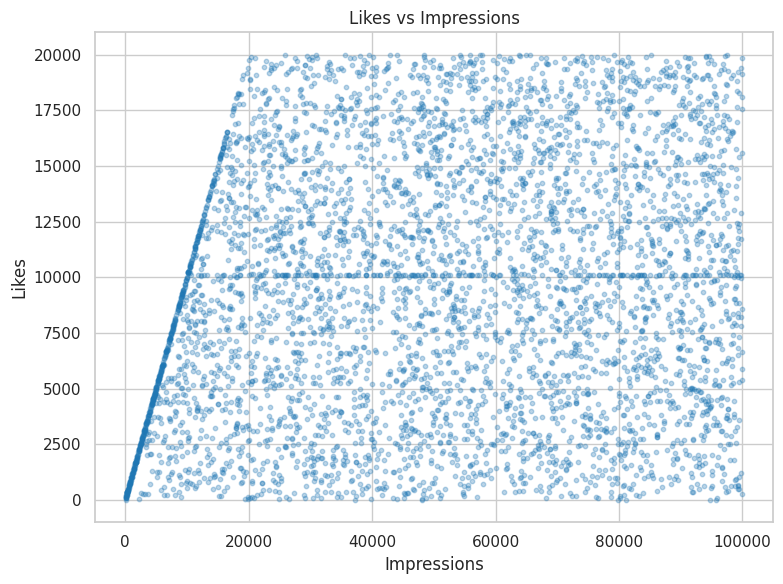

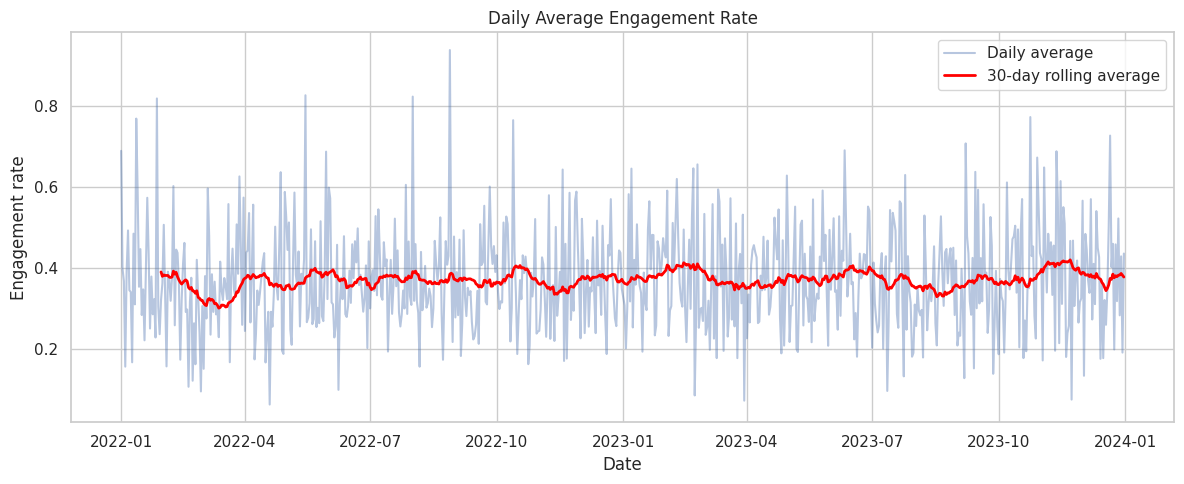

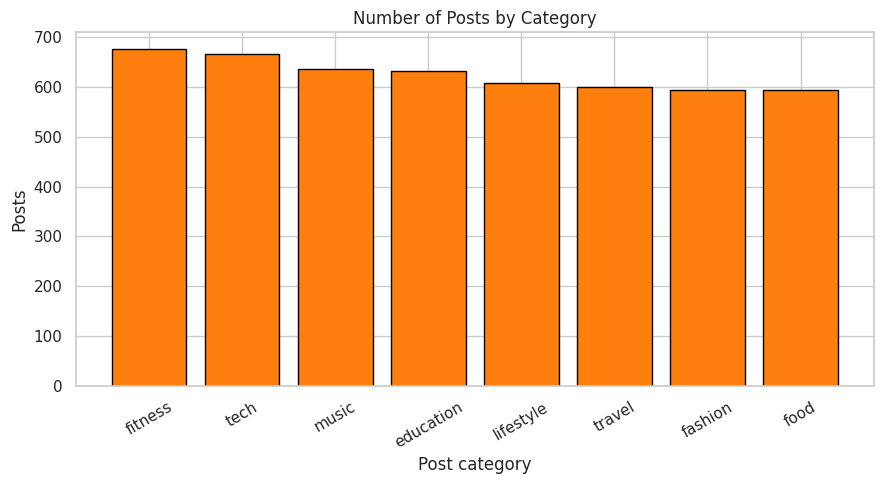

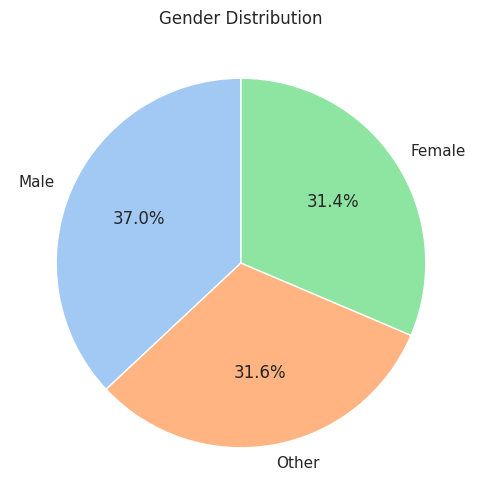

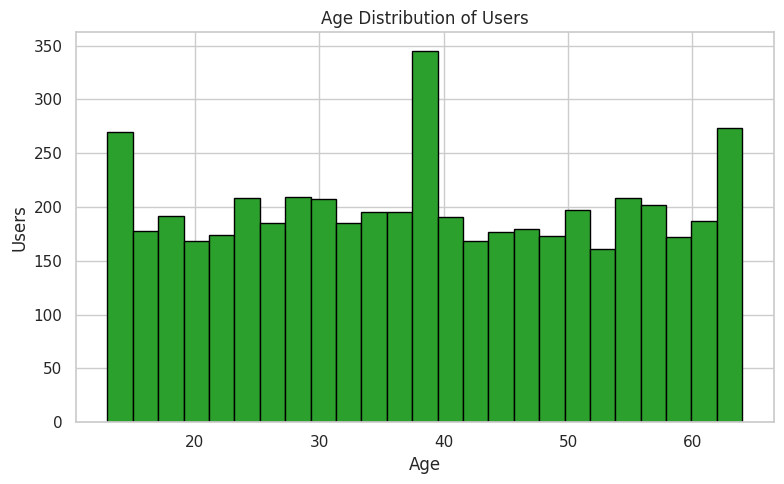

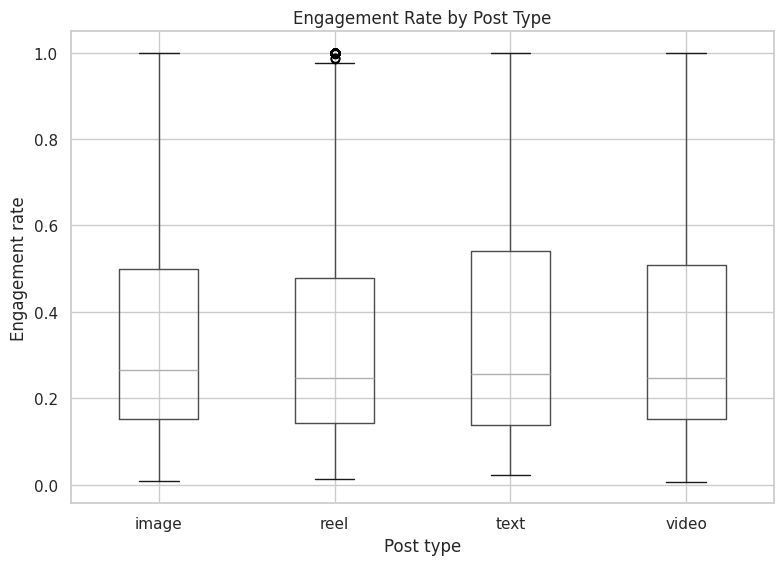

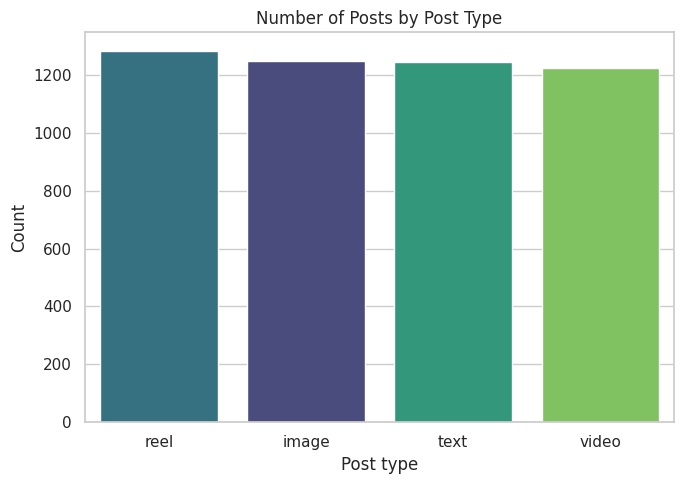

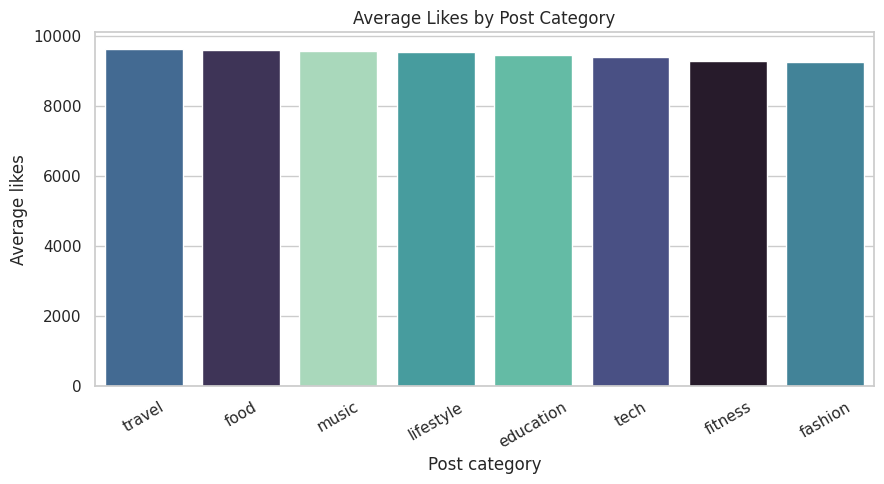

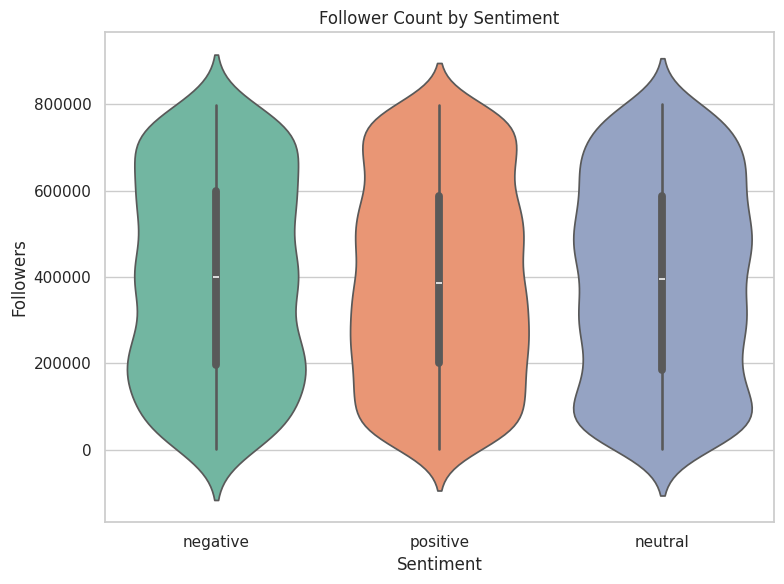

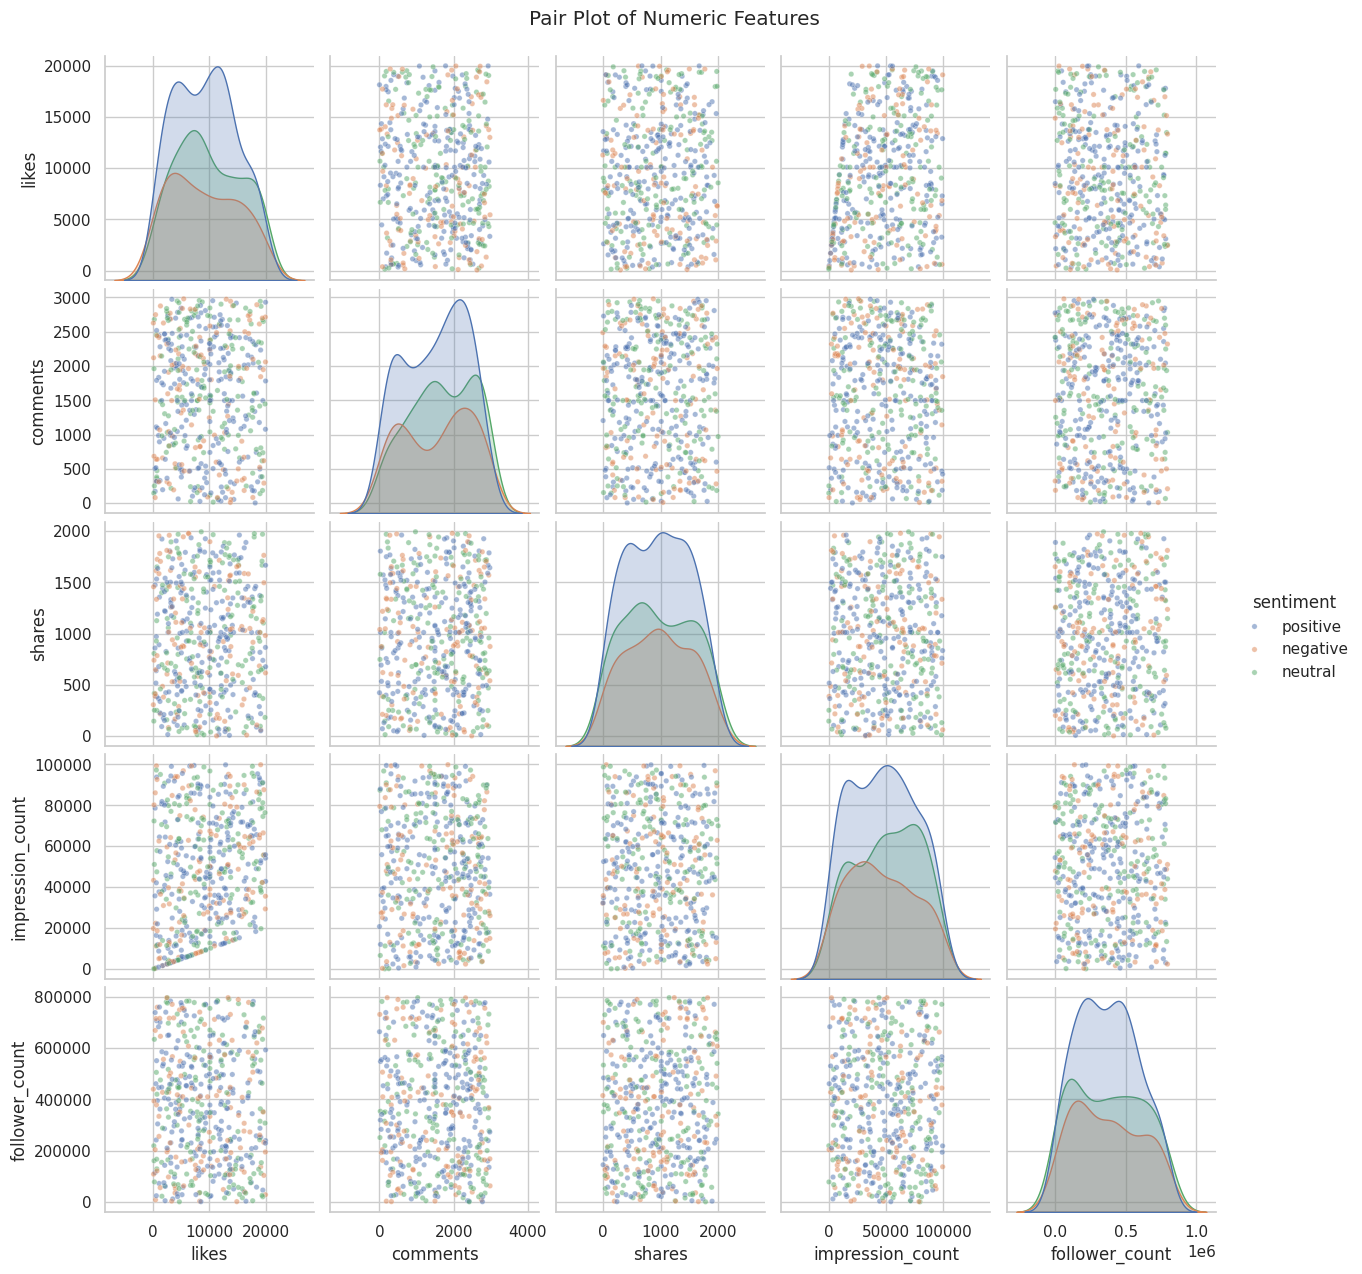

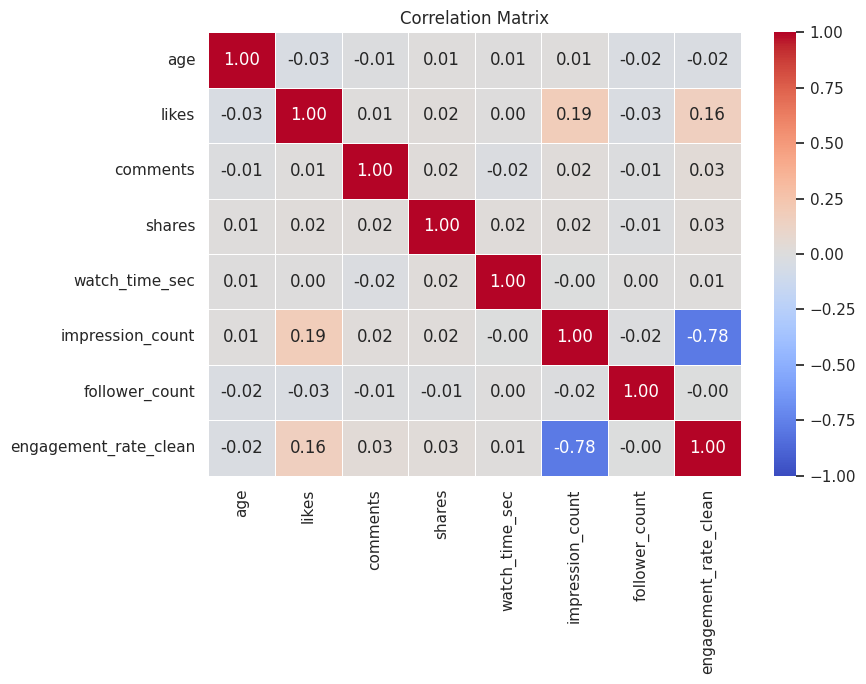

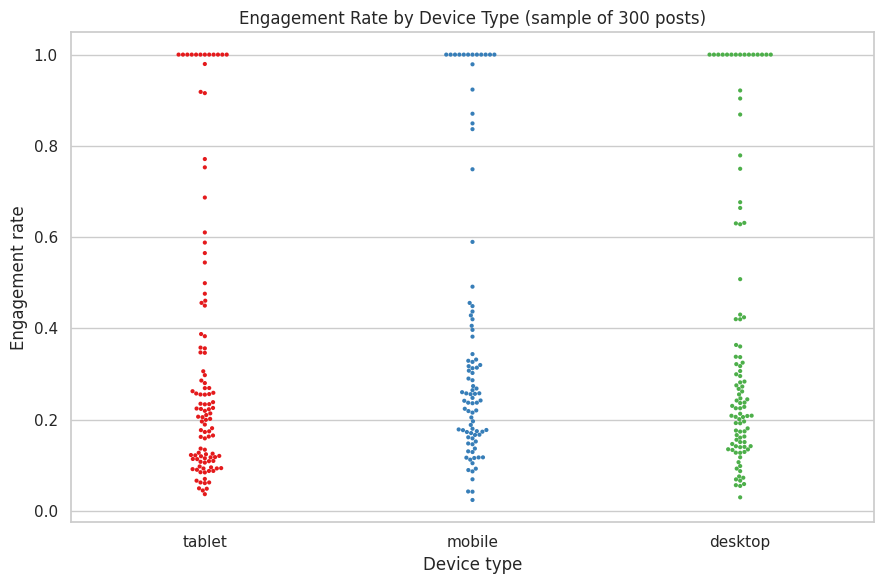

=== CONTENT PERFORMANCE ===
Engagement rate by post type:
 post_type
text     0.3761
video    0.3757
image    0.3737
reel     0.3601
Name: engagement_rate_clean, dtype: float64
Engagement rate by category:
 post_category
fitness      0.3842
music        0.3798
education    0.3785
lifestyle    0.3710
tech         0.3696
travel       0.3652
fashion      0.3629
food         0.3568
Name: engagement_rate_clean, dtype: float64
Engagement rate by country:
 country
Australia    0.3945
Japan        0.3846
UAE          0.3829
Germany      0.3797
Canada       0.3777
Brazil       0.3756
France       0.3673
USA          0.3589
UK           0.3552
India        0.3397
Name: engagement_rate_clean, dtype: float64

=== USER TRENDS ===
Engagement rate by age group:
 age_group
13-17    0.398351
18-24    0.368095
25-34    0.374779
35-44    0.371584
45-54    0.372341
55-64    0.355458
Name: engagement_rate_clean, dtype: float64
Corr(age, engagement rate): -0.024
Verified vs not:
              engagement_rat

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
# TASK 1 — Data Import & Setup
df = pd.read_csv("https://github.com/Bharat-KR25/Numpy-and-pandas-projects/raw/refs/heads/main/social_media_engagement_5000.csv")
print("Shape:", df.shape)
df.head()
# Convert posted_at (dd-mm-yyyy text) to datetime
df["posted_at"] = pd.to_datetime(df["posted_at"], format="%d-%m-%Y")
df["is_verified"] = df["is_verified"].astype(bool)

print(df["posted_at"].dtype, df["is_verified"].dtype)
print("Date range:", df["posted_at"].min().date(), "to", df["posted_at"].max().date())

# TASK 2 — Data Cleaning
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nMissing % :")
print((df.isnull().mean() * 100).round(2)[missing > 0])

for col in ["age", "likes", "comments", "shares"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["gender", "sentiment"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values left:", df.isnull().sum().sum())
# ---- 2.2 Duplicates ----
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate post_ids (different content, so kept):", df["post_id"].duplicated().sum())
print("Shape after de-duplication:", df.shape)

# ---- 2.3 Data formatting & standardisation ----
for col in ["age", "likes", "comments", "shares"]:
    df[col] = df[col].astype(int)

for col in ["gender", "post_type", "post_category", "device_type", "sentiment"]:
    df[col] = df[col].str.strip().str.lower()
df["country"] = df["country"].str.strip()

gender_map = {"m": "Male", "male": "Male", "f": "Female", "female": "Female"}
df["gender"] = df["gender"].str.lower().map(gender_map).fillna("Other")

for col in ["gender", "post_type", "post_category", "device_type", "sentiment", "country"]:
    print(col, "->", sorted(df[col].unique()))

# ---- Unrealistic values ----
print("Negative values:", (df[["likes","comments","shares"]] < 0).sum().sum())
print("Rows where likes > impressions:", (df["likes"] > df["impression_count"]).sum())
print("Rows where total interactions > impressions:",
      ((df["likes"] + df["comments"] + df["shares"]) > df["impression_count"]).sum())
print("Rows with engagement_rate > 1:", (df["engagement_rate"] > 1).sum())
print("Max engagement_rate:", df["engagement_rate"].max())

for col in ["likes", "comments", "shares"]:
    df[col] = df[col].clip(lower=0, upper=df["impression_count"])

df["engagement_rate_clean"] = df["engagement_rate"].clip(lower=0, upper=1)
print("Rows where engagement_rate was capped:", (df["engagement_rate"] > 1).sum())
df[["engagement_rate", "engagement_rate_clean"]].describe()

# ---- 2.5 Feature cleaning: hashtags & sentiment ----
df["hashtag_count"] = df["hashtags"].str.count("#")
df["sentiment"] = df["sentiment"].str.strip().str.lower()
print(df["hashtag_count"].value_counts().sort_index())
print(df["sentiment"].value_counts())
# TASK 3 — Data Exploration using Pandas
print(df.head())
print(df.tail())
print("Shape:", df.shape)
print("Columns:", list(df.columns))

df.info()

print(df.describe().T)

cat_cols = ["gender", "country", "post_type", "post_category", "device_type", "sentiment"]
print(df[cat_cols].nunique(), "\n")
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

num_cols = ["age", "likes", "comments", "shares", "watch_time_sec",
            "impression_count", "follower_count", "engagement_rate_clean"]
corr = df[num_cols].corr()
print(corr.round(2))

print("Average likes by post type")
print(df.groupby("post_type")["likes"].mean().round(0).sort_values(ascending=False))
print("Average impressions by country")
print(df.groupby("country")["impression_count"].mean().round(0).sort_values(ascending=False))
print("Average engagement rate by post category")
print(df.groupby("post_category")["engagement_rate_clean"].mean().round(4).sort_values(ascending=False))

print(df.loc[0:4, ["post_type", "likes", "impression_count"]])
print(df.iloc[:3, :5])
print("Verified reels with > 15,000 likes:",
      len(df[(df["is_verified"]) & (df["post_type"] == "reel") & (df["likes"] > 15000)]))
# TASK 4 — Data Wrangling
df["total_interactions"] = df["likes"] + df["comments"] + df["shares"]
df["engagement_score"] = df["likes"] * 1 + df["comments"] * 2 + df["shares"] * 3
df["log_likes"] = np.log1p(df["likes"])
df["log_impressions"] = np.log1p(df["impression_count"])
df["log_followers"] = np.log1p(df["follower_count"])
df["year"] = df["posted_at"].dt.year
df["month"] = df["posted_at"].dt.month
df["day_of_week"] = df["posted_at"].dt.day_name()
df["age_group"] = pd.cut(df["age"], bins=[12, 17, 24, 34, 44, 54, 64],
                         labels=["13-17", "18-24", "25-34", "35-44", "45-54", "55-64"])

country_stats = (df.groupby("country")
                   .agg(country_avg_er=("engagement_rate_clean", "mean"),
                        country_avg_impressions=("impression_count", "mean"))
                   .reset_index())
df = df.merge(country_stats, on="country", how="left")

top_bottom = pd.concat([df.nlargest(5, "engagement_score"),
                        df.nsmallest(5, "engagement_score")])
print(top_bottom[["post_id", "post_type", "post_category", "country", "engagement_score"]])

agg = {"likes": "mean", "comments": "mean", "shares": "mean",
       "impression_count": "mean", "engagement_rate_clean": "mean", "engagement_score": "mean"}
for key in ["post_type", "country", "sentiment"]:
    print(f"=== Summary by {key} ===")
    print(df.groupby(key).agg(agg).round(3).sort_values("engagement_rate_clean", ascending=False))
    # TASK 5 — Statistical Analysis
    stat_cols = ["likes", "comments", "shares", "watch_time_sec", "engagement_rate_clean", "follower_count"]

stats = pd.DataFrame({
    "mean": df[stat_cols].mean(),
    "median": df[stat_cols].median(),
    "mode": [df[c].mode()[0] for c in stat_cols],
    "std": df[stat_cols].std(),
    "variance": df[stat_cols].var(),
    "min": df[stat_cols].min(),
    "p25": df[stat_cols].quantile(0.25),
    "p50": df[stat_cols].quantile(0.50),
    "p75": df[stat_cols].quantile(0.75),
    "p90": df[stat_cols].quantile(0.90),
    "p95": df[stat_cols].quantile(0.95),
    "max": df[stat_cols].max(),
    "skewness": df[stat_cols].skew(),
    "kurtosis": df[stat_cols].kurt(),
})
print(stats.round(4))
# TASK 6 — Data Visualization (16 plots
# ---- Matplotlib ----
plt.figure(figsize=(8, 6))
plt.scatter(df["impression_count"], df["likes"], alpha=0.3, s=10, color="tab:blue")
plt.title("Likes vs Impressions")
plt.xlabel("Impressions"); plt.ylabel("Likes")
plt.tight_layout(); plt.show()

daily = df.groupby("posted_at")["engagement_rate_clean"].mean()
plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, alpha=0.4, label="Daily average")
plt.plot(daily.index, daily.rolling(30).mean(), color="red", linewidth=2, label="30-day rolling average")
plt.title("Daily Average Engagement Rate")
plt.xlabel("Date"); plt.ylabel("Engagement rate")
plt.legend(); plt.tight_layout(); plt.show()

cat_counts = df["post_category"].value_counts()
plt.figure(figsize=(9, 5))
plt.bar(cat_counts.index, cat_counts.values, color="tab:orange", edgecolor="black")
plt.title("Number of Posts by Category")
plt.xlabel("Post category"); plt.ylabel("Posts")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

g = df["gender"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(g, labels=g.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=25, color="tab:green", edgecolor="black")
plt.title("Age Distribution of Users")
plt.xlabel("Age"); plt.ylabel("Users")
plt.tight_layout(); plt.show()

df.boxplot(column="engagement_rate_clean", by="post_type", figsize=(8, 6))
plt.suptitle("")
plt.title("Engagement Rate by Post Type")
plt.xlabel("Post type"); plt.ylabel("Engagement rate")
plt.tight_layout(); plt.show()

# ---- Seaborn ----
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="post_type", hue="post_type",
              order=df["post_type"].value_counts().index, palette="viridis", legend=False)
plt.title("Number of Posts by Post Type")
plt.xlabel("Post type"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 5))
order = df.groupby("post_category")["likes"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="post_category", y="likes", hue="post_category",
            order=order, palette="mako", errorbar=None, legend=False)
plt.title("Average Likes by Post Category")
plt.xlabel("Post category"); plt.ylabel("Average likes")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x="sentiment", y="follower_count", hue="sentiment", palette="Set2", legend=False)
plt.title("Follower Count by Sentiment")
plt.xlabel("Sentiment"); plt.ylabel("Followers")
plt.tight_layout(); plt.show()

sample = df.sample(500, random_state=42)
g = sns.pairplot(sample, vars=["likes", "comments", "shares", "impression_count", "follower_count"],
                 hue="sentiment", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
g.figure.suptitle("Pair Plot of Numeric Features", y=1.02)
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout(); plt.show()

swarm = df.sample(300, random_state=1)
plt.figure(figsize=(9, 6))
sns.swarmplot(data=swarm, x="device_type", y="engagement_rate_clean", hue="device_type",
              palette="Set1", size=3, legend=False)
plt.title("Engagement Rate by Device Type (sample of 300 posts)")
plt.xlabel("Device type"); plt.ylabel("Engagement rate")
plt.tight_layout(); plt.show()

# ---- Plotly (interactive) ----
monthly = (df.assign(month_start=df["posted_at"].dt.to_period("M").dt.to_timestamp())
             .groupby("month_start")["engagement_rate_clean"].mean().reset_index())
fig = px.line(monthly, x="month_start", y="engagement_rate_clean", markers=True,
              title="Monthly Average Engagement Rate",
              labels={"month_start": "Month", "engagement_rate_clean": "Avg engagement rate"})
fig.show()

by_country = df.groupby("country")["engagement_rate_clean"].mean().sort_values(ascending=False).reset_index()
fig = px.bar(by_country, x="country", y="engagement_rate_clean", color="engagement_rate_clean",
             title="Average Engagement Rate by Country",
             labels={"engagement_rate_clean": "Avg engagement rate"})
fig.show()

cat = (df.groupby("post_category")
         .agg(avg_likes=("likes", "mean"), avg_impr=("impression_count", "mean"),
              avg_followers=("follower_count", "mean"), posts=("post_id", "count"))
         .reset_index())
fig = px.scatter(cat, x="avg_impr", y="avg_likes", size="avg_followers", color="post_category",
                 hover_data=["posts"], size_max=50,
                 title="Category Performance: Impressions vs Likes (bubble = avg followers)")
fig.show()

fig = px.scatter(df.sample(1000, random_state=7), x="impression_count", y="likes", color="post_type",
                 hover_data=["country", "sentiment"],
                 title="Likes vs Impressions by Post Type")
fig.show()
print("=== CONTENT PERFORMANCE ===")
print("Engagement rate by post type:\n", df.groupby("post_type")["engagement_rate_clean"].mean().round(4).sort_values(ascending=False))
print("Engagement rate by category:\n", df.groupby("post_category")["engagement_rate_clean"].mean().round(4).sort_values(ascending=False))
print("Engagement rate by country:\n", df.groupby("country")["engagement_rate_clean"].mean().round(4).sort_values(ascending=False))

print("\n=== USER TRENDS ===")
print("Engagement rate by age group:\n", df.groupby("age_group", observed=True)["engagement_rate_clean"].mean())
print("Corr(age, engagement rate):", round(df["age"].corr(df["engagement_rate_clean"]), 3))
print("Verified vs not:\n", df.groupby("is_verified")[["engagement_rate_clean", "likes", "impression_count", "follower_count"]].mean().round(3))

print("\n=== BEHAVIOURAL ===")
dow = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
print("Avg impressions by day of week:\n", df.groupby("day_of_week")["impression_count"].mean().reindex(dow).round(0))
print("Watch time by device:\n", df.groupby("device_type")["watch_time_sec"].mean().round(1))

print("\n=== SENTIMENT ===")
print(df.groupby("sentiment")[["engagement_rate_clean", "engagement_score", "likes", "comments", "shares"]].mean().round(3))

